In [1]:
!wget "https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv"

--2025-05-01 02:10:37--  https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv [following]
--2025-05-01 02:10:37--  https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1032085 (1008K) [text/plain]
Saving to: ‘clientes_segmentos (1).csv’

clientes_segmento

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from datetime import datetime
from scipy.stats import gaussian_kde

In [3]:
df = pd.read_csv("clientes_segmentos (1).csv")

In [4]:
df.head()

,id_cliente,edad,genero,ingresos,plataforma,interacciones,compras,promedio_ticket,total_gastado,fecha_primer_compra,fecha_ultima_compra,dias_desde_ultima,recomendaciones,costo_adquisicion
0,C00000,36,F,41869,Facebook,18,2,114,228,2023-06-02,2024-12-25,97,0,25
1,C00001,53,F,57074,Facebook,16,1,88,88,2024-02-13,2025-03-08,24,0,24
2,C00002,36,F,47859,Instagram,29,3,23,69,2023-07-27,2025-03-05,27,1,16
3,C00003,55,F,53656,Facebook,17,1,47,47,2024-01-08,2025-02-16,44,0,29
4,C00004,47,F,46759,Facebook,15,1,102,102,2024-02-12,2025-02-07,53,0,32


In [5]:
df['fecha_ultima_compra'] = pd.to_datetime(df['fecha_ultima_compra'])


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_cliente           15000 non-null  object        
 1   edad                 15000 non-null  int64         
 2   genero               15000 non-null  object        
 3   ingresos             15000 non-null  int64         
 4   plataforma           15000 non-null  object        
 5   interacciones        15000 non-null  int64         
 6   compras              15000 non-null  int64         
 7   promedio_ticket      15000 non-null  int64         
 8   total_gastado        15000 non-null  int64         
 9   fecha_primer_compra  15000 non-null  object        
 10  fecha_ultima_compra  15000 non-null  datetime64[ns]
 11  dias_desde_ultima    15000 non-null  int64         
 12  recomendaciones      15000 non-null  int64         
 13  costo_adquisicion    15000 non-

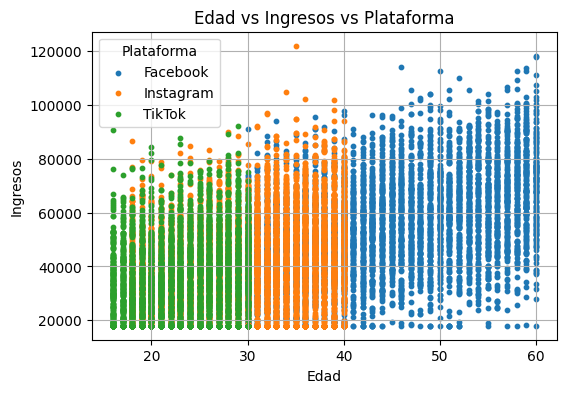

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
platforms = df['plataforma'].unique()

for platform in platforms:
    subset = df[df['plataforma'] == platform]
    plt.scatter(subset['edad'], subset['ingresos'], label=platform, s=10)

plt.xlabel('Edad')
plt.ylabel('Ingresos')
plt.title('Edad vs Ingresos vs Plataforma')
plt.legend(title='Plataforma')
plt.grid(True)
plt.show()



P1. La plataforma con mejor equilibrio entre el nivel de ingreso de los usuarios y su rango de edad es Instagram.

-Si el público objetivo está compuesto por jóvenes, lo más efectivo sería hacer publicidad en TikTok.

-En caso de que se busque llegar a personas con mayores ingresos y de una edad más avanzada, Facebook sería la opción más adecuada.


In [20]:
hoy = datetime(2025, 4, 30)
df['Recency'] = (hoy - df['fecha_ultima_compra']).dt.days
df['Frequency'] = df['compras']
df['Monetary'] = df['total_gastado']

rfm = df[['Recency', 'Frequency', 'Monetary']]

correlacion = rfm.corr()
print("\nMatriz de correlación RFM:\n", correlacion)


Matriz de correlación RFM:
             Recency  Frequency  Monetary
Recency    1.000000  -0.003188 -0.003745
Frequency -0.003188   1.000000  0.633622
Monetary  -0.003745   0.633622  1.000000


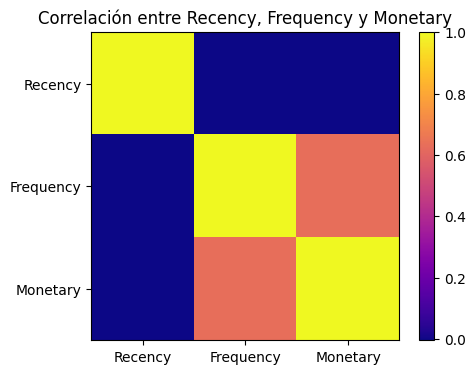

In [27]:
plt.figure(figsize=(5, 4))
plt.imshow(correlacion, cmap='plasma', interpolation='none')
plt.xticks(range(len(correlacion.columns)), correlacion.columns)
plt.yticks(range(len(correlacion.index)), correlacion.index)
plt.colorbar()
plt.title('Correlación entre Recency, Frequency y Monetary')
plt.show()

In [28]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
clusters = kmeans.fit_predict(rfm_scaled)

df['cluster'] = clusters
print("\nSegmentos RFM asignados a cada cliente:")
print(df[['id_cliente', 'Recency', 'Frequency', 'Monetary', 'cluster']])


Segmentos RFM asignados a cada cliente:
      id_cliente  Recency  Frequency  Monetary  cluster
0         C00000      126          2       228        0
1         C00001       53          1        88        1
2         C00002       56          3        69        1
3         C00003       73          1        47        1
4         C00004       82          1       102        1
...          ...      ...        ...       ...      ...
14995     C14995       82          3       150        0
14996     C14996      153          4       456        0
14997     C14997      201          3       171        0
14998     C14998      190          1        27        1
14999     C14999       81          1        16        1

[15000 rows x 5 columns]


P2. La combinación de las variables que ofrecen una visión más completa del consumidor son Frequency y Monetary ya que Frequency indica cuán seguido compra, lo cual refleja su nivel de fidelidad, mientras que Monetary aporta información adicional sobre el monto que gasta.

**Fase 2 – Métricas de Negocio (CAC, LTV, ROI)**

P3

In [29]:
hoy = datetime(2025, 4, 30)
df['dias_desde_ultima'] = (hoy - df['fecha_ultima_compra']).dt.days
df['activo'] = df['dias_desde_ultima'] <= 180

In [30]:
resumen = df.groupby('plataforma').agg(
    total_clientes=('id_cliente', 'count'),
    clientes_activos=('activo', 'sum'),
    cac_total=('costo_adquisicion', 'sum')
).reset_index()

In [31]:
resumen['porc_activos'] = resumen['clientes_activos'] / resumen['total_clientes']
resumen['CAC_ponderado'] = resumen['cac_total'] * resumen['porc_activos']

In [32]:
plt.figure(figsize=(6, 4))
bar_width = 0.4
x = np.arange(len(resumen))


<Figure size 600x400 with 0 Axes>

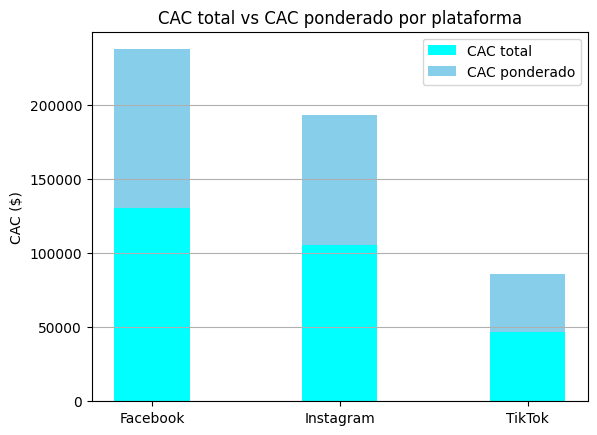

In [35]:
plt.bar(x, resumen['cac_total'], width=bar_width, label='CAC total', color='cyan')
plt.bar(x, resumen['CAC_ponderado'], width=bar_width, label='CAC ponderado', color='skyblue', bottom=resumen['cac_total'])

plt.xticks(x, resumen['plataforma'])
plt.ylabel('CAC ($)')
plt.title('CAC total vs CAC ponderado por plataforma')
plt.legend()
plt.grid(axis='y')
plt.show()

P4

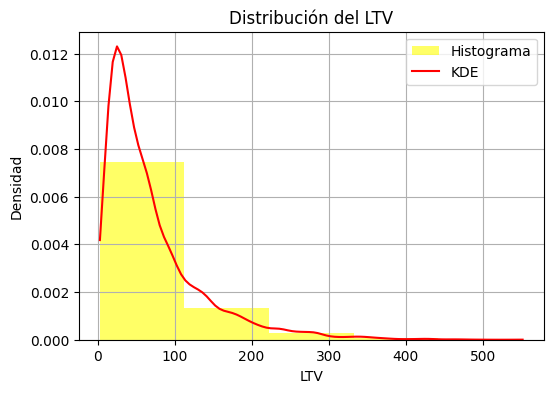

In [39]:

df['fecha_ultima_compra'] = pd.to_datetime(df['fecha_ultima_compra'])

#LTV
df['promedio_ticket'] = df['total_gastado'] / df['compras']
df['frecuencia_mensual'] = df['compras'] / 12

# Tasa ret.
def retencion(dias):
    if dias <= 90:
        return 0.80
    elif dias <= 180:
        return 0.60
    else:
        return 0.30

# Días desde la última compra
hoy = pd.to_datetime("2025-04-30")
df['dias_desde_ultima'] = (hoy - df['fecha_ultima_compra']).dt.days
df['tasa_retencion'] = df['dias_desde_ultima'].apply(retencion)

# Calcular LTV
df['LTV'] = df['promedio_ticket'] * df['frecuencia_mensual'] * 12 * df['tasa_retencion']


plt.figure(figsize=(6, 4))
counts, bins, patches = plt.hist(df['LTV'], bins=5, density=True, alpha=0.6, color='yellow', label='Histograma')

# KDE
kde = gaussian_kde(df['LTV'])
x_vals = np.linspace(min(df['LTV']), max(df['LTV']), 100)
plt.plot(x_vals, kde(x_vals), color='red', label='KDE')

#Gráfico
plt.xlabel('LTV')
plt.ylabel('Densidad')
plt.title('Distribución del LTV')
plt.legend()
plt.grid(True)
plt.show()

P5

<ipython-input-40-868fa32b1ba4>:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['plataforma'] == plat]['margen'] for plat in df['plataforma'].unique()],


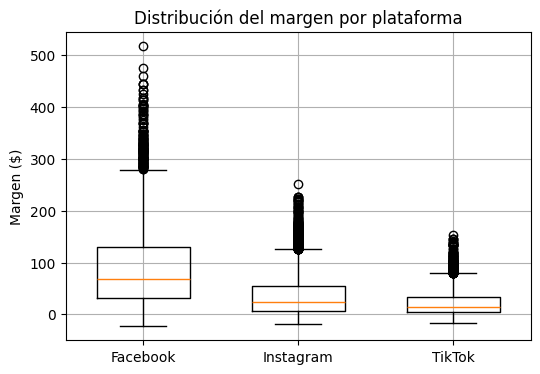

In [40]:
df['margen'] = (df['promedio_ticket'] * df['frecuencia_mensual'] * 12 * df['tasa_retencion']) - df['costo_adquisicion']


plt.figure(figsize=(6, 4))
plt.boxplot([df[df['plataforma'] == plat]['margen'] for plat in df['plataforma'].unique()],
            labels=df['plataforma'].unique(), widths=0.6)

# Gráfico
plt.ylabel('Margen ($)')
plt.title('Distribución del margen por plataforma')
plt.grid(True)
plt.show()

La gráfica arroja que la que tiene mejor márgen promedio es Facebook, después se ubica Instagram.

**Fase 3 – Segmentación y Modelado**

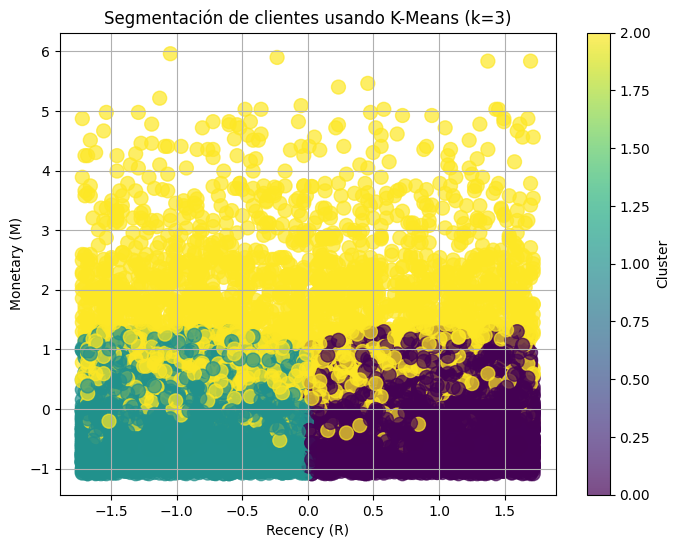

In [43]:
df['dias_desde_ultima'] = (pd.to_datetime("2025-04-30") - df['fecha_ultima_compra']).dt.days
df['recency'] = df['dias_desde_ultima']
df['frequency'] = df['compras']
df['monetary'] = df['total_gastado']

scaler = StandardScaler()
df[['recency', 'frequency', 'monetary']] = scaler.fit_transform(df[['recency', 'frequency', 'monetary']])


kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['recency', 'frequency', 'monetary']])

names_and_slogans = {
    0: ("Cluster 1", "Rentabilidad alta"),
    1: ("Cluster 2", "Rentabilidad media"),
    2: ("Cluster 3", "Rentabilidad baja")
}

df['cluster_name'] = df['cluster'].map(lambda x: names_and_slogans[x][0])
df['cluster_slogan'] = df['cluster'].map(lambda x: names_and_slogans[x][1])

#Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(df['recency'], df['monetary'], c=df['cluster'], cmap='viridis', s=100, alpha=0.7)
plt.xlabel('Recency (R)')
plt.ylabel('Monetary (M)')
plt.title('Segmentación de clientes usando K-Means (k=3)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [44]:
df.cluster.value_counts()

,count
cluster,
0,5829
1,5784
2,3387


In [46]:
percentil_75 = np.percentile(df['monetary'], 75)
df['high_margin'] = (df['monetary'] >= percentil_75).astype(int)

print(df[['id_cliente', 'cluster_name', 'cluster_slogan', 'high_margin']])

      id_cliente cluster_name      cluster_slogan  high_margin
0         C00000    Cluster 3   Rentabilidad baja            1
1         C00001    Cluster 2  Rentabilidad media            0
2         C00002    Cluster 2  Rentabilidad media            0
3         C00003    Cluster 2  Rentabilidad media            0
4         C00004    Cluster 2  Rentabilidad media            0
...          ...          ...                 ...          ...
14995     C14995    Cluster 2  Rentabilidad media            0
14996     C14996    Cluster 3   Rentabilidad baja            1
14997     C14997    Cluster 1   Rentabilidad alta            1
14998     C14998    Cluster 1   Rentabilidad alta            0
14999     C14999    Cluster 2  Rentabilidad media            0

[15000 rows x 4 columns]


**Fase 4 – Decisión Estratégica**

P9

In [47]:
margen_promedio = df.groupby('cluster')['margen'].mean().sort_values(ascending=False)

mejor_cluster = margen_promedio.index[0]
segundo_mejor = margen_promedio.index[1]

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['recency', 'frequency', 'monetary']])

margen_promedio = df.groupby('cluster')['monetary'].mean()
df['cluster_name'] = df['cluster'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

In [51]:
inversion = 10000
cluster_1_roi = (margen_promedio[0] * inversion - inversion) / inversion

In [ ]:
cluster_2_roi = (margen_promedio[1] * inversion - inversion) / inversion

In [53]:
total_margen = margen_promedio.sum()
proporcion_cluster_0 = margen_promedio[0] / total_margen
proporcion_cluster_1 = margen_promedio[1] / total_margen
proporcion_cluster_2 = margen_promedio[2] / total_margen

inversion_0 = inversion * proporcion_cluster_0
inversion_1 = inversion * proporcion_cluster_1
inversion_2 = inversion * proporcion_cluster_2

In [54]:

roi_escenario_0 = (margen_promedio[0] * inversion_0 - inversion_0) / inversion_0
roi_escenario_1 = (margen_promedio[1] * inversion_1 - inversion_1) / inversion_1
roi_escenario_2 = (margen_promedio[2] * inversion_2 - inversion_2) / inversion_2


In [55]:
resultados = {
    'Escenario': ['Concentrar en Cluster 1', 'Distribuir en Cluster 1 y 2', 'Distribuir proporcionalmente'],
    'ROI Esperado': [roi_escenario_0, roi_escenario_1, roi_escenario_2]
}

resultados_df = pd.DataFrame(resultados)
print(resultados_df)

                      Escenario  ROI Esperado
0       Concentrar en Cluster 1     -1.376120
1   Distribuir en Cluster 1 y 2     -1.387821
2  Distribuir proporcionalmente      0.309582


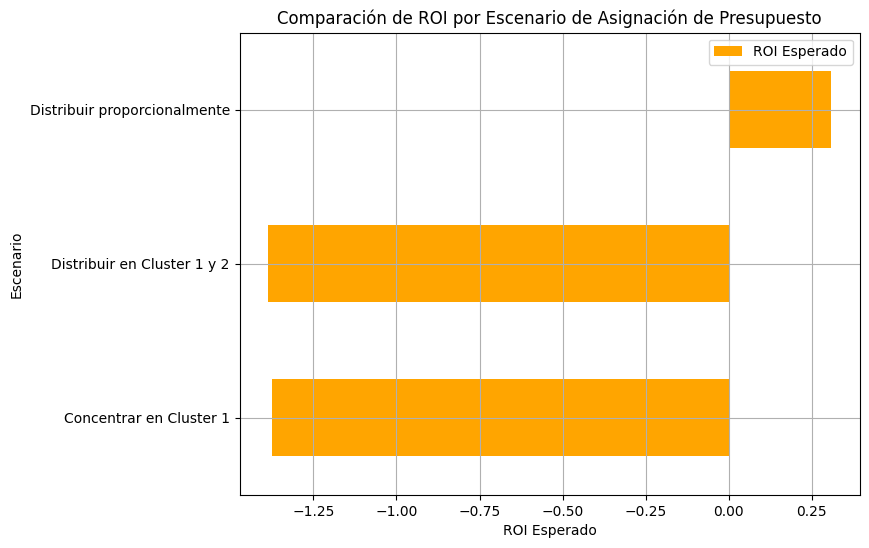

In [57]:
resultados_df.set_index('Escenario').plot(kind='barh', figsize=(8, 6), color=['orange', 'lightgreen', 'lightcoral'])
plt.title('Comparación de ROI por Escenario de Asignación de Presupuesto')
plt.xlabel('ROI Esperado')
plt.grid(True)
plt.show()

Cluster 1 debería ser el foco pues es el único que demostró tener un ROI positivo. Esta es la forma más conveniente de realizar una inversión monetaria.

P10

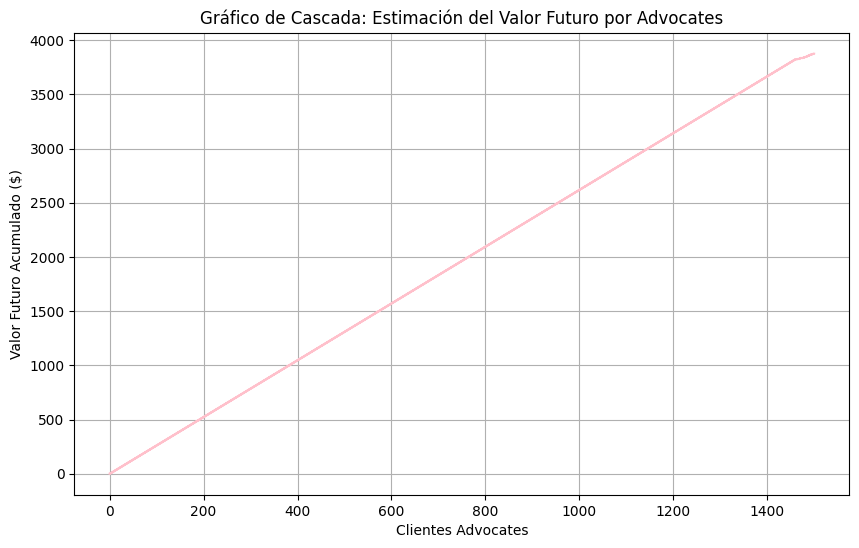

In [60]:
df['margen'] = df['monetary']
top_10_percent = df.nlargest(int(len(df) * 0.1), 'margen')

clientes_nuevos = 2
valor_futuro_total = 0

for index, row in top_10_percent.iterrows():
    cluster = row['cluster']
    valor_cliente_nuevo = margen_promedio[cluster]
    valor_futuro_total += clientes_nuevos * valor_cliente_nuevo

import matplotlib.pyplot as plt
valores = [0] + [clientes_nuevos * margen_promedio[cluster] for cluster in top_10_percent['cluster']]
cumulative_values = np.cumsum(valores)

#Gráfico
plt.figure(figsize=(10, 6))
plt.step(range(len(cumulative_values)), cumulative_values, where='post', color='pink', label="Valor Futuro")
plt.xlabel('Clientes Advocates')
plt.ylabel('Valor Futuro Acumulado ($)')
plt.title('Gráfico de Cascada: Estimación del Valor Futuro por Advocates')
plt.grid(True)
plt.show()

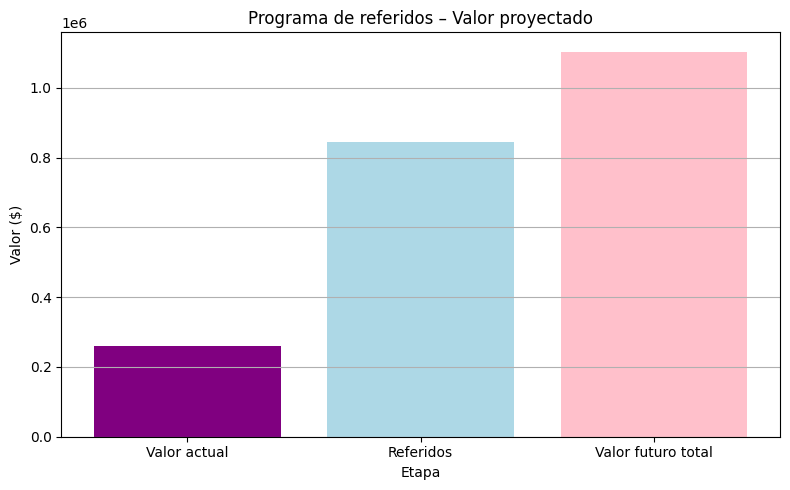

In [66]:
df['promedio_ticket'] = df['total_gastado'] / df['compras']
df['frecuencia_mensual'] = df['compras'] / 3
df['dias_ultima'] = (pd.to_datetime("2025-04-30") - df['fecha_ultima_compra']).dt.days
df['tasa_retencion'] = df['dias_ultima'].apply(lambda x: 0.8 if x <= 90 else 0.6 if x <= 180 else 0.3)
df['LTV'] = df['promedio_ticket'] * df['frecuencia_mensual'] * 12 * df['tasa_retencion']

umbral = df['interacciones'].quantile(0.90)
advocates = df[df['interacciones'] >= umbral]

ltv_prom_cluster = df.groupby('cluster')['LTV'].mean()

valor_referidos = advocates.apply(lambda x: 2 * ltv_prom_cluster[x['cluster']], axis=1).sum()

valor_actual = advocates['LTV'].sum()

valor_total = valor_actual + valor_referidos

etapas = ['Valor actual', 'Referidos', 'Valor futuro total']
valores = [valor_actual, valor_referidos, valor_total]

#Gráfico
plt.figure(figsize=(8, 5))
plt.bar(etapas[:2], valores[:2], color=['purple', 'lightblue'])
plt.bar(etapas[2], valores[2], color='pink')
plt.xlabel('Etapa')
plt.title('Programa de referidos – Valor proyectado')
plt.ylabel('Valor ($)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

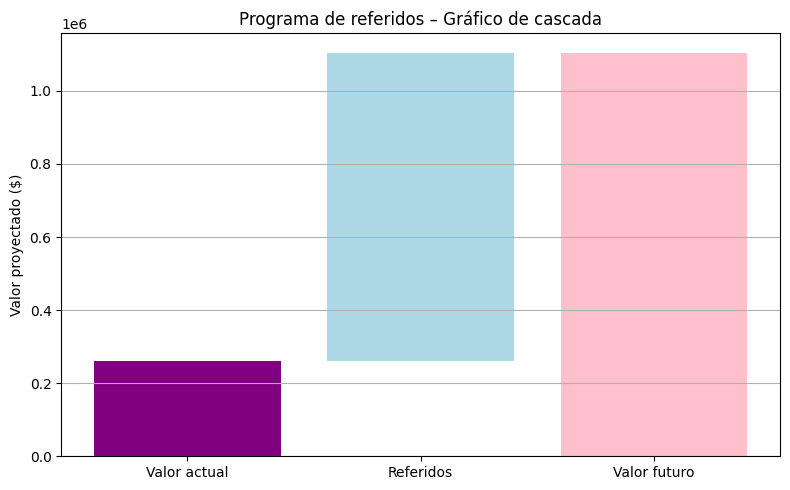

In [68]:
etapas = ['Valor actual', 'Referidos', 'Valor futuro']
valores = [valor_actual, valor_referidos, 0]

acumulado = [valores[0], valores[0] + valores[1], valores[0] + valores[1]]

colores = ['purple', 'lightblue', 'pink']

start = [0, acumulado[0], 0]
height = [valores[0], valores[1], acumulado[1]]

plt.figure(figsize=(8, 5))
for i in range(3):
    plt.bar(etapas[i], height[i] if i < 2 else height[i], bottom=start[i], color=colores[i])

#Gráfico
plt.title('Programa de referidos – Gráfico de cascada')
plt.ylabel('Valor proyectado ($)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Fase 5 – Reflexión Crítica**

P11

Un posible sesgo puede ser el tiempo de los datos, ya que las tendencias pueden estar influenciadas por modas o estaciones del año, lo que haría que las predicciones solo sirvan en condiciones similares, como cuando hay la misma popularidad en redes sociales o las mismas estaciones del año. Esto significa que solo podríamos hacer predicciones en situaciones parecidas, limitando la exactitud a largo plazo.

Otro sesgo puede ser el sesgo de compra. No saber cuántos clientes potenciales visitan la tienda o el sitio web puede ser un problema. Por ejemplo, puede haber un grupo de personas, como los jóvenes, interesados en un producto pero que no lo compran por falta de dinero. Esto puede resultar en perder a ese cliente porque no tenemos un producto que se ajuste a sus necesidades por lo que es importante entender las limitaciones de los consumidores para ofrecer productos que se adapten mejor a ellos.

Finalmente, la falta de información sobre las formas de pago también genera un sesgo. Sin saber qué métodos de pago prefieren los clientes, es difícil diseñar campañas efectivas o entender si las ventas provienen de una tienda física o de un canal online. Esto limita las estrategias de marketing y hace que los costos sean más altos. Saber qué métodos de pago utilizan los clientes nos ayuda a crear campañas más específicas y rentables.

*Posibles mejoras*

1.  Incorporar variables estacionales y realizar análisis a largo plazo para evitar sesgos temporales y mejorar las predicciones.

2. Realizar una segmentación más detallada de clientes y ofrecer diversas opciones de pago para adaptarse a diferentes necesidades económicas y preferencias.


In [69]:

perfil_cluster = df.groupby('cluster').agg(
    tamano_cluster=('id_cliente', 'count'),
    edad_promedio=('edad', 'mean'),
    ingresos_promedio=('ingresos', 'mean'),
    total_gastado_promedio=('total_gastado', 'mean')
).reset_index()

print(perfil_cluster)


   cluster  tamano_cluster  edad_promedio  ingresos_promedio  \
0        0            5829      32.002230       42710.466632   
1        1            5784      31.784578       43027.287344   
2        2            3387      36.778270       47175.881311   

   total_gastado_promedio  
0               78.513810  
1               77.384509  
2              241.204606  


In [73]:
df['LTV'] = df['total_gastado'] * df['compras'] * 12

df['Margen'] = df['LTV'] - df['costo_adquisicion']

tabla_ltv_cac_margen = df.groupby('cluster').agg(
    LTV_promedio=('LTV', 'mean'),
    CAC_promedio=('costo_adquisicion', 'mean'),
    Margen_promedio=('Margen', 'mean')
).reset_index()

print(tabla_ltv_cac_margen)

tabla_ltv_cac_margen = df.groupby('cluster').agg(
    LTV_promedio=('LTV', 'mean'),
    CAC_promedio=('costo_adquisicion', 'mean'),
    Margen_promedio=('Margen', 'mean')
).reset_index()

print(tabla_ltv_cac_margen)


   cluster  LTV_promedio  CAC_promedio  Margen_promedio
0        0   1941.840453     18.203637      1923.636816
1        1   1890.763485     18.241355      1872.522130
2        2  11610.239150     20.983466     11589.255683
   cluster  LTV_promedio  CAC_promedio  Margen_promedio
0        0   1941.840453     18.203637      1923.636816
1        1   1890.763485     18.241355      1872.522130
2        2  11610.239150     20.983466     11589.255683


In [74]:
tabla_ltv_cac_margen['ROI'] = (tabla_ltv_cac_margen['Margen_promedio'] / tabla_ltv_cac_margen['CAC_promedio'])

print(tabla_ltv_cac_margen)

   cluster  LTV_promedio  CAC_promedio  Margen_promedio         ROI
0        0   1941.840453     18.203637      1923.636816  105.673213
1        1   1890.763485     18.241355      1872.522130  102.652576
2        2  11610.239150     20.983466     11589.255683  552.304161
